## Librerías

In [1]:
# 1. Instalación silenciosa de dependencias externas
!pip install -q ucimlrepo

# 2. Manejo de datos y computación científica
import numpy as np
import pandas as pd

# 3. Visualización y Estética
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Herramientas de Machine Learning (Scikit-Learn)
from sklearn import datasets
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import StratifiedShuffleSplit, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 5. Ingesta de datos externos
from ucimlrepo import fetch_ucirepo

# Configuración de visualización en el notebook
%matplotlib inline
sns.set_theme(style="whitegrid") # Opcional: establece un tema base elegante

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

# Parte 1: Clasificación Logística

**Clasificación Binaria con Datos Sintéticos**

A diferencia de la regresión lineal, donde buscamos predecir un valor continuo, en la **Clasificación Logística** nuestro objetivo es asignar una etiqueta (clase 0 o clase 1) a una observación basada en sus características.

Generaremos un dataset sintético con dos variables independientes ($X_1, X_2$) que sea mayormente separable, pero introduciendo un porcentaje de ruido para simular un escenario real donde las clases pueden traslaparse ligeramente.

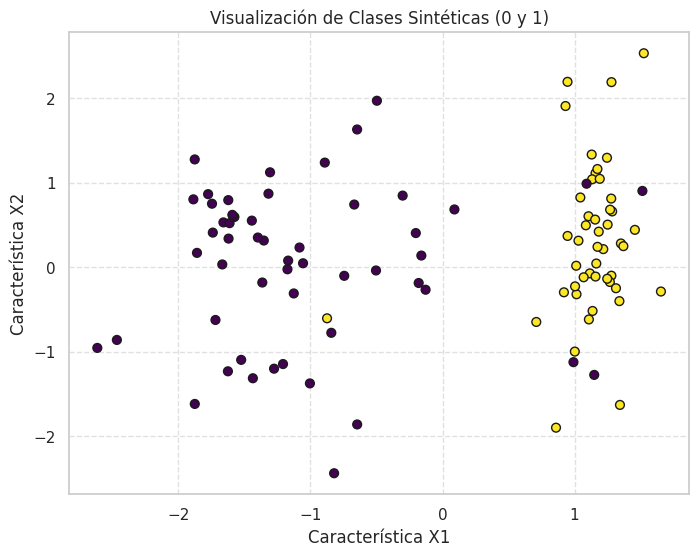

In [2]:
# Generación de datos de dos tipos con ruido (flip_y)
# n_informative=1 indica que solo una de las variables es realmente útil para separar las clases
X1, Y1 = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=1,
    n_clusters_per_class=1,
    random_state=1,
    class_sep=1.2,
    flip_y=0.15
)

# Visualización de los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=40, edgecolor="k", cmap='viridis')
plt.title("Visualización de Clases Sintéticas (0 y 1)")
plt.xlabel("Característica X1")
plt.ylabel("Característica X2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**La Función Logística (Sigmoide)**

> **Podemos establecer un clasificador de los sistemas basado en las probabilidades a partir de un clasificador logístico:**
> $$f(z) = \frac{1}{1 + e^{-z}}$$
> **Cuya derivada es:**
> $$f'(z) = f(z)(1 - f(z))$$



La regresión lineal produce valores en el rango $(-\infty, \infty)$. Sin embargo, para clasificar, necesitamos un valor acotado en $(0, 1)$ que represente la probabilidad $P(y=1|x)$. La función sigmoide cumple esta tarea:
* Si $z$ es muy grande y positivo, $f(z) \to 1$.
* Si $z$ es muy grande y negativo, $f(z) \to 0$.
* Si $z = 0$, $f(z) = 0.5$ (punto crítico de decisión).

In [3]:
# Definición de la función sigmoide
f = lambda x: 1 / (1 + np.exp(-x))

# Definición de la derivada de la función sigmoide
fp = lambda x: f(x) * (1 - f(x))

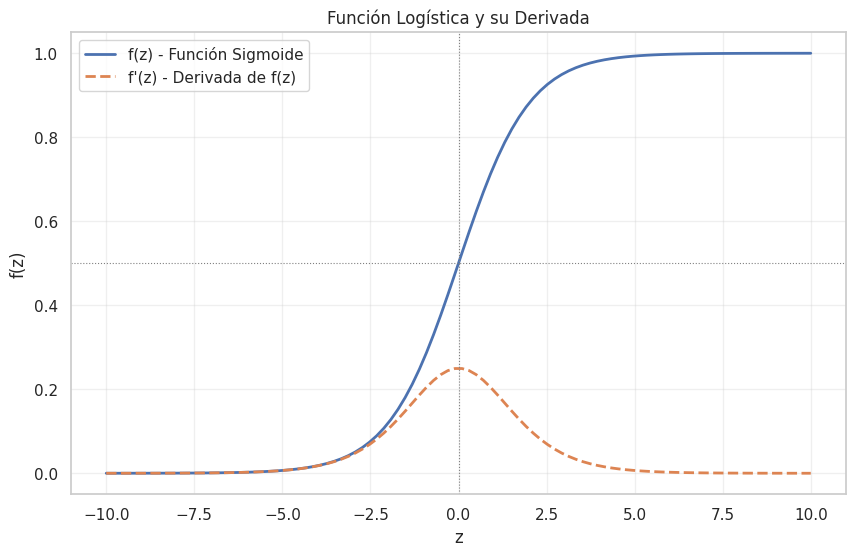

In [4]:
# Generamos un rango de valores para z
z = np.linspace(-10, 10, 100)

plt.figure(figsize=(10, 6))

# Graficamos la sigmoide y su derivada
plt.plot(z, f(z), label="f(z) - Función Sigmoide", linewidth=2)
plt.plot(z, fp(z), label="f'(z) - Derivada de f(z)", linestyle='--', linewidth=2)

# Referencias visuales para el punto de decisión
plt.axhline(0.5, color='gray', linewidth=0.8, linestyle=':')
plt.axvline(0, color='gray', linewidth=0.8, linestyle=':')

plt.title("Función Logística y su Derivada")
plt.xlabel("z")
plt.ylabel("f(z)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretación del punto de decisión**

> * **Para valores de $z < 0.0$ la regresión logística clasifica objetos tipo 0, siendo $f(z) < 0.5$**
> * **Para valores de $z \geq 0.0$ la regresión logística clasifica objetos tipo 1 siendo $f(z) \geq 0.5$**

En la práctica, $z$ será el resultado de nuestra combinación lineal $\Theta^T X$. El signo de este resultado determinará de qué lado de la "frontera" cae el dato.

**Fronteras de Decisión**

> **Las condiciones anteriores permiten definir fronteras de desicion entre los datos a clasificar. Para los datos dados arriba, se puede establecer el siguiente clasificador:**
> $$h_\theta(x) = g(\theta_0 + \theta_1 x_1 + \theta_2 x_2)$$
> **Una clasificación del dataset nos sugiere que la frontera para este dataset es:**
> $$\theta_0 + \theta_1 x_1 + \theta_2 x_2 \geq 0.0$$
> **Si por algun metodo encontramos que los parametros $\Theta$ entonces podemos definir la frontera de clasifiación. Como ejemplo supongamos que encontramos los siguientes parametros $\Theta = [3.0, -20, 1.0]$**

La frontera de decisión es el lugar geométrico donde la probabilidad es exactamente $0.5$, lo cual ocurre cuando el argumento de la sigmoide es cero ($\Theta^T X = 0$). Para el caso de dos variables, esto describe una recta:
$$\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$$

Despejando $x_2$ para poder graficarla en el plano cartesiano:
$$x_2 = -\frac{\theta_1}{\theta_2} x_1 - \frac{\theta_0}{\theta_2}$$

Con los valores propuestos $\Theta = [3, -20, 1]$, la ecuación resulta en:
$$x_2 = 20x_1 - 3$$

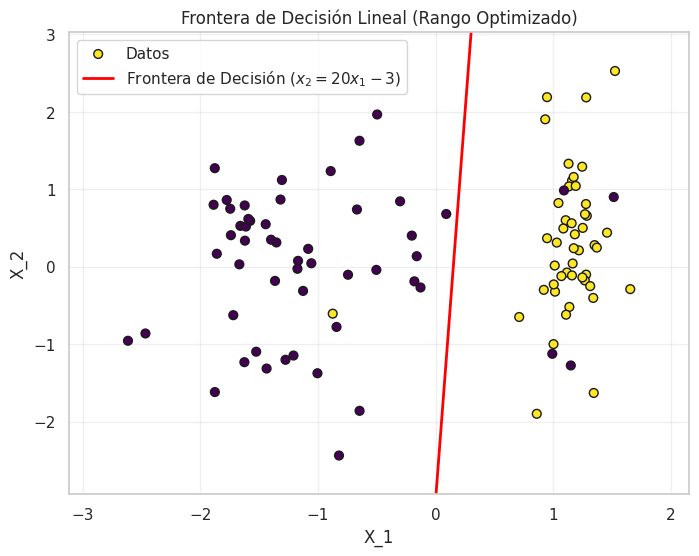

In [5]:


# Identificamos los límites reales de nuestros datos en el eje X1
x1_min, x1_max = X1[:, 0].min(), X1[:, 0].max()

# Generamos el linspace basándonos en esos límites (con un pequeño margen de 0.1)
x1_boundary = np.linspace(x1_min - 0.1, x1_max + 0.1, 100)
x2_boundary = 20 * x1_boundary - 3

plt.figure(figsize=(8, 6))

# Graficamos los datos
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=40, edgecolor="k", cmap='viridis', label="Datos")

# Graficamos la frontera de decisión (ahora cruzará todo el gráfico)
plt.plot(x1_boundary, x2_boundary, color='red', linewidth=2, label="Frontera de Decisión ($x_2 = 20x_1 - 3$)")

# Ajustamos los límites de visualización para que el gráfico no se deforme
plt.ylim(X1[:, 1].min() - 0.5, X1[:, 1].max() + 0.5)
plt.xlim(x1_min - 0.5, x1_max + 0.5)

plt.title("Frontera de Decisión Lineal (Rango Optimizado)")
plt.xlabel("X_1")
plt.ylabel("X_2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Fronteras No Lineales**

> **Fronteras no lineal también puede ser consideradas, para ello se puede definir $\Theta^T X$ como funcion de un polinomio, por ejemplo:**
> $$\Theta^T X = \theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_1^2 + \theta_4x_2^2$$
> **La frontera de desición en este caso esta determinada por:**
> $$\theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_1^2 + \theta_4x_2^2 \geq 0$$

Cuando los datos presentan una estructura concéntrica, una combinación lineal simple de $x_1$ y $x_2$ fallará. Sin embargo, si añadimos términos de orden superior (como $x^2$), estamos proyectando los datos a un espacio de mayor dimensión donde una frontera "lineal" en ese nuevo espacio corresponde a una curva en el espacio original.


**Generación de Datos Circulares**

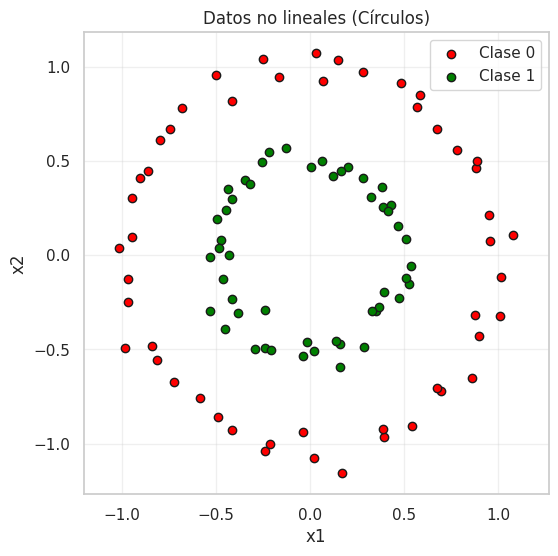

In [6]:
# Generamos datos concéntricos
X_circles, y_circles = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=0)

# Separamos para facilitar el color en la gráfica
reds = y_circles == 0
greens = y_circles == 1

plt.figure(figsize=(6, 6))
plt.scatter(X_circles[reds, 0], X_circles[reds, 1], c="red", edgecolors='k', label="Clase 0")
plt.scatter(X_circles[greens, 0], X_circles[greens, 1], c="green", edgecolors='k', label="Clase 1")
plt.title("Datos no lineales (Círculos)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

**Definición de la Frontera Circular**

> **Analizando el conjunto de datos, se puede observar que la frontera es la de una circunferencia con centro en (0, 0) y radio de 0.7 aproximadamente, así nuestra elección de parámetros para el polinomio es $\Theta^T = [-0.7, 0, 0, 1, 1]$. Reemplazando tenemos que:**
> $$-0.7 + x_1^2 + x_2^2 \geq 0 \implies x_1^2 + x_2^2 \geq 0.7$$

Para visualizar esta frontera, parametrizaremos la ecuación del círculo:
$x = r \cdot \cos(\alpha)$;
$y = r \cdot \sin(\alpha)$

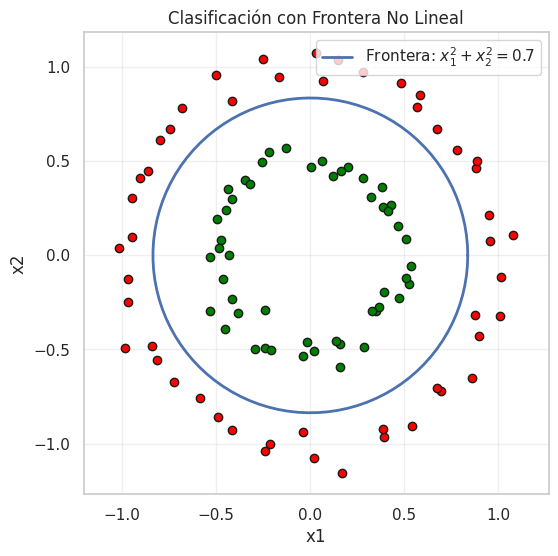

In [7]:
# Creamos la frontera circular (radio sqrt(0.7) approx 0.83)
# Nota: El PDF menciona radio 0.7, pero la ecuación x^2 + y^2 = 0.7 implica r = sqrt(0.7)
angulo = np.linspace(0, 2*np.pi, 100)
r = np.sqrt(0.7)
x1_circle = r * np.cos(angulo)
x2_circle = r * np.sin(angulo)

plt.figure(figsize=(6, 6))
plt.scatter(X_circles[reds, 0], X_circles[reds, 1], c="red", edgecolors='k')
plt.scatter(X_circles[greens, 0], X_circles[greens, 1], c="green", edgecolors='k')

# Dibujamos la frontera de decisión circular
plt.plot(x1_circle, x2_circle, "b-", linewidth=2, label="Frontera: $x_1^2 + x_2^2 = 0.7$")

plt.title("Clasificación con Frontera No Lineal")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="upper right")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

**Análisis técnico:**
Este ejemplo demuestra que la "linealidad" de la regresión logística se refiere a los **parámetros $\Theta$**, no a las características $X$. Al transformar $X$, podemos crear fronteras de decisión de cualquier complejidad geométrica.

**La Función de Coste en Clasificación**

> **Podemos definir la función de coste como:**
> $$J(\Theta) = \frac{1}{m} \sum_{i=1}^{m} [-y^{(i)} \log(h_\theta(x^{(i)})) - (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))]$$
> **Esta función garantiza que cuando $P(y=1|x, \theta)$ se cumple, la función de coste se minimiza, penalizando los valores que se alejan de la realidad.**

A diferencia de la regresión lineal, no usamos el Error Cuadrático Medio porque, al combinarlo con la sigmoide, produciría una superficie "no convexa" llena de mínimos locales donde el gradiente descendente se quedaría atrapado. La función de **Entropía Cruzada** (mostrada arriba) es convexa y permite una optimización global eficiente.

**Demostración Analítica del Gradiente**

> **Se deja como tarea mostrar que:**
> $$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} [h_\theta(x^{(i)}) - y^{(i)}]x_j^{(i)}$$

Para demostrar esta igualdad, utilizaremos la regla de la cadena. Definamos primero los componentes:
1. Hipótesis: $h_\theta(x) = g(z)$, donde $g(z) = \frac{1}{1 + e^{-z}}$ y $z = \sum \theta_j x_j$.
2. Derivada de la sigmoide: $g'(z) = g(z)(1 - g(z))$.
3. Derivada de $z$ respecto a $\theta_j$: $\frac{\partial z}{\partial \theta_j} = x_j$.

**Desarrollo de la derivada para una sola muestra:**

$$\frac{\partial J}{\partial \theta_j} = \frac{\partial}{\partial \theta_j} [ -y \log(g(z)) - (1-y) \log(1-g(z)) ]$$

Aplicando la regla de la cadena:
$$\frac{\partial J}{\partial \theta_j} = \left( \frac{-y}{g(z)} \cdot g'(z) - \frac{1-y}{1-g(z)} \cdot (-g'(z)) \right) \cdot \frac{\partial z}{\partial \theta_j}$$

Sustituyendo $g'(z)$ por $g(z)(1-g(z))$:
$$\frac{\partial J}{\partial \theta_j} = \left( \frac{-y}{g(z)} [g(z)(1-g(z))] + \frac{1-y}{1-g(z)} [g(z)(1-g(z))] \right) \cdot x_j$$

Simplificando términos:
$$\frac{\partial J}{\partial \theta_j} = \left( -y(1-g(z)) + (1-y)g(z) \right) \cdot x_j$$
$$\frac{\partial J}{\partial \theta_j} = \left( -y + yg(z) + g(z) - yg(z) \right) \cdot x_j$$
$$\frac{\partial J}{\partial \theta_j} = (g(z) - y)x_j$$

Al promediar sobre las $m$ muestras, obtenemos la ecuación final solicitada. Es notable que la forma del gradiente sea **idéntica** a la de la regresión lineal, aunque la función $h_\theta(x)$ sea diferente.

**Interpretación Probabilística (MLE)**

> **¿Qué tan adecuada es la elección de $J(\theta)$ para el modelo de regresión logística?**
> **Asumiendo que los datos de entrenamiento son independientes, la probabilidad total (Verosimilitud) es:**
> $$L(\theta) = \prod_{i=1}^{m} [h_\theta(x^{(i)})]^{y^{(i)}} [1 - h_\theta(x^{(i)})]^{1-y^{(i)}}$$

Al aplicar el logaritmo natural a la Verosimilitud ($L(\theta)$) para convertir los productos en sumas y maximizar la probabilidad de que el modelo explique los datos observados, obtenemos exactamente la función de coste de Entropía Cruzada (con signo invertido). Esto demuestra que minimizar nuestro coste es equivalente a encontrar el escenario estadístico más probable.


**Regularización en Regresión Logística**

> **Disminuir la complejidad del algoritmo.**
> **Función de coste:**
> $$J(\Theta) = \frac{1}{m} \sum_{i=1}^{m} [-y^{(i)} \log(h_\theta(x^{(i)})) - (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))] + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$
> **Derivada de la función de coste:**
> $$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} [h_\theta(x^{(i)}) - y^{(i)}]x_j^{(i)} + \frac{\lambda}{m}\theta_j$$

La regularización añadida es de tipo **$L_2$** (o Ridge). El término $\frac{\lambda}{2m} \sum \theta_j^2$ actúa como un "presupuesto": si los valores de $\theta$ crecen demasiado para intentar pasar por cada punto ruidoso, el coste $J$ aumenta drásticamente. El parámetro **$\lambda$** controla este equilibrio:
* Si $\lambda$ es muy alto, el modelo es muy simple (riesgo de *underfitting*).
* Si $\lambda$ es cero, no hay regularización (riesgo de *overfitting*).


**Actualización de Parámetros (Gradiente Descendente)**

> **El gradiente descendente puede ser escrito como:**
> $$\theta_j := \theta_j \left(1 - \alpha \frac{\lambda}{m}\right) - \frac{\alpha}{m} \sum_{i=1}^{m} [h_\theta(x^{(i)}) - y^{(i)}]x_j^{(i)}$$

En la práctica, al actualizar $\theta_j$, primero lo multiplicamos por un factor ligeramente menor a 1 ($1 - \alpha \frac{\lambda}{m}$), lo que efectivamente "encoge" el parámetro en cada paso antes de aplicar la corrección del error.

**Nota técnica importante:** Por convención, el término de intercepto ($\theta_0$) **no se regulariza**, ya que su magnitud solo desplaza la frontera pero no aumenta la complejidad de la "curvatura" del modelo. Por ello, la sumatoria de la penalización suele empezar en $j=1$.

**La Ecuación Normal para Clasificación**

> **Normal equation:**
> $$\theta = (X^T X + \lambda L)^{-1} X^T y$$
> Donde $L$ es una matriz identidad con el primer elemento en cero para no regularizar el intercepto.

Aunque la regresión logística no tiene una "solución cerrada" exacta como la regresión lineal (debido a la función sigmoide no lineal), se pueden utilizar aproximaciones iterativas basadas en la Ecuación Normal (como el algoritmo de Mínimos Cuadrados Re-ponderados Iterativamente - IRLS). En estos casos, la matriz $\lambda L$ asegura que la matriz resultante sea siempre invertible y que los pesos se mantengan controlados.

# Parte 2: Iris Database

**Clasificación Multiclase: Estrategia "Uno contra Todos"**

> **Si en un dataset existen más de 2 clases, $y = 0, 1, 2, 3, \dots$ se debe construir una multiclasificación, una contra todos, la estrategia sugerida es la siguiente.**
>
> **Sea A, B, C las tres clases. Para estos valores definir:**
> 1. **Definir la clase A como la clase 0 y todas las otras B, C como la clase 1.**
> 2. **Encontrar el valor $h_\theta(X) = P(y = A|x; \theta)$.**
> 3. **Definir la clase B como la clase 0 y todas las otras A, C como la clase 1.**
> 4. **Encontrar el valor $h_\theta(X) = P(y = B|x; \theta)$.**
> 5. **Definir la clase C como la clase 0 y todas las otras A, B como la clase 1.**
> 6. **Encontrar el valor $h_\theta(X) = P(y = C|x; \theta)$.**

En lugar de intentar encontrar una frontera que separe las tres clases a la vez, entrenamos **$n$ clasificadores binarios independientes** (donde $n$ es el número de clases).

Para predecir la clase de un nuevo dato, ejecutamos los tres modelos y observamos cuál de ellos arroja la probabilidad más alta. La clase cuyo modelo tenga el valor más cercano a 1 será la ganadora.



> **1. Para tener una vision general de los datos analiza lo que contiene la clave DESCR del dataset**

In [8]:
# 1. Cargamos el dataset Iris
iris = datasets.load_iris()


> **2. Construye un dataframe:**
> * **los datos se pueden encontrar con la clave "data".**
> * **los nombres de las caracteristicas con la clave: "feature_names"**
> * **La clave target nos permite indentificar el tipo de datos.**

In [9]:
# 2. Construcción del DataFrame inicial
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['Target'] = iris.target

> **3. Cambia el nombre de las columnas del dataframe, empleando intrucción como:**
>
> `columns_name =[ "".join([c.capitalize() for c in cols.split()]) for cols in df.columns ]`
> `columns_name =[col.replace("(" ,"_") for col in columns_name ]`
> `cols = [col.replace(")" ,"") for col in columns_name ]`

In [10]:
# 3. Limpieza de nombres de columnas según la lógica solicitada
# Esta transformación convierte 'sepal length (cm)' en 'SepalLength_cm'
cols_originales = df_iris.columns
new_cols = [ "".join([c.capitalize() for c in col.split()]) for col in cols_originales ]
new_cols = [ col.replace("(", "_") for col in new_cols ]
new_cols = [ col.replace(")", "") for col in new_cols ]

# Asignamos los nuevos nombres
df_iris.columns = new_cols

print("Nuevos nombres de columnas:")
print(df_iris.columns.tolist())
display(df_iris.head())

Nuevos nombres de columnas:
['SepalLength_cm', 'SepalWidth_cm', 'PetalLength_cm', 'PetalWidth_cm', 'Target']


,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


> **4. Analizar el dataframe, numeros de datos, cantidad de null, descripción del dataframe.**

In [11]:
# Análisis de estructura y nulos
print("Resumen de información:")
df_iris.info()

print("\nValores nulos por columna:")
print(df_iris.isnull().sum())

Resumen de información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SepalLength_cm  150 non-null    float64
 1   SepalWidth_cm   150 non-null    float64
 2   PetalLength_cm  150 non-null    float64
 3   PetalWidth_cm   150 non-null    float64
 4   Target          150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Valores nulos por columna:
SepalLength_cm    0
SepalWidth_cm     0
PetalLength_cm    0
PetalWidth_cm     0
Target            0
dtype: int64


> **5. Aplica estadística básica y construye graficas para entender el dataset.**

In [12]:
# Estadísticas descriptivas
display(df_iris.describe())

,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


> **6. Encontrar la matrix de correlacion, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap().**

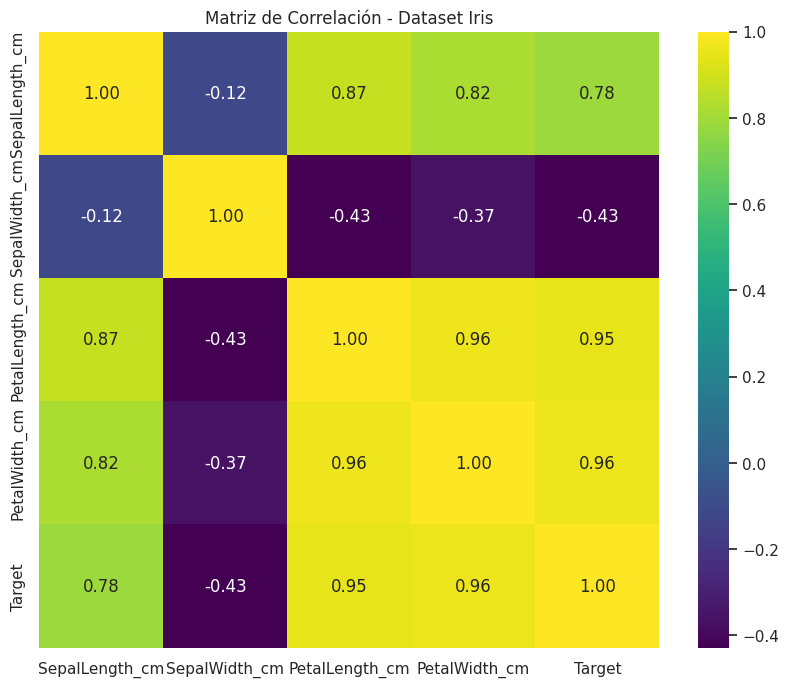

In [13]:
# Matriz de correlación y visualización
plt.figure(figsize=(10, 8))
corr_matrix = df_iris.corr()
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Matriz de Correlación - Dataset Iris")
plt.show()

> **7. Separar los datos en datos de entramiento y test, prueba la siguiente instruccion:**
>
> `split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)`

In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

# Inicializamos el separador estratificado
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Realizamos la partición basada en la columna 'Target'
for train_index, test_index in split.split(df_iris, df_iris["Target"]):
    strat_train_set = df_iris.loc[train_index]
    strat_test_set = df_iris.loc[test_index]

print(f"Tamaño del set de entrenamiento: {len(strat_train_set)}")
print(f"Tamaño del set de prueba: {len(strat_test_set)}")

# Verificación de proporciones (debe haber 40 de cada clase en entrenamiento)
print("\nDistribución de clases en el set de entrenamiento:")
print(strat_train_set["Target"].value_counts())

Tamaño del set de entrenamiento: 120
Tamaño del set de prueba: 30

Distribución de clases en el set de entrenamiento:
Target
0    40
2    40
1    40
Name: count, dtype: int64


> **8. Construye un modelo empleando una regresión logística, para clasificar la clase setosa y no setosa, emplea la libreria sklearn.**

In [15]:
# Preparamos los datos: X = PetalWidth_cm, y = Es Setosa (Clase 0)
X_train_bin = strat_train_set[["PetalWidth_cm"]].values
# Creamos una etiqueta binaria: 1 si es Setosa (0), 0 si es cualquier otra
y_train_bin = (strat_train_set["Target"] == 0).astype(int)

# Inicializamos y entrenamos el modelo
log_reg = LogisticRegression(solver='lbfgs', random_state=42)
log_reg.fit(X_train_bin, y_train_bin)

# Generamos nuevos datos para observar la curva de probabilidad
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
# predict_proba devuelve [Probabilidad de 0, Probabilidad de 1]
y_proba = log_reg.predict_proba(X_new)

> **9. Determine la frontera de clasificación.**

In [16]:
# Determinamos la frontera de decisión (donde la probabilidad es 0.5)
# Buscamos el valor de X donde la probabilidad de ser Setosa cruza el 50%
decision_boundary = X_new[y_proba[:, 1] >= 0.5][-1]

print(f"Frontera de decisión encontrada en PetalWidth_cm: {decision_boundary[0]:.2f} cm")

Frontera de decisión encontrada en PetalWidth_cm: 0.76 cm



> **10. Encontrar una gráfica de la regresión logística con los valores de probabilidad.**

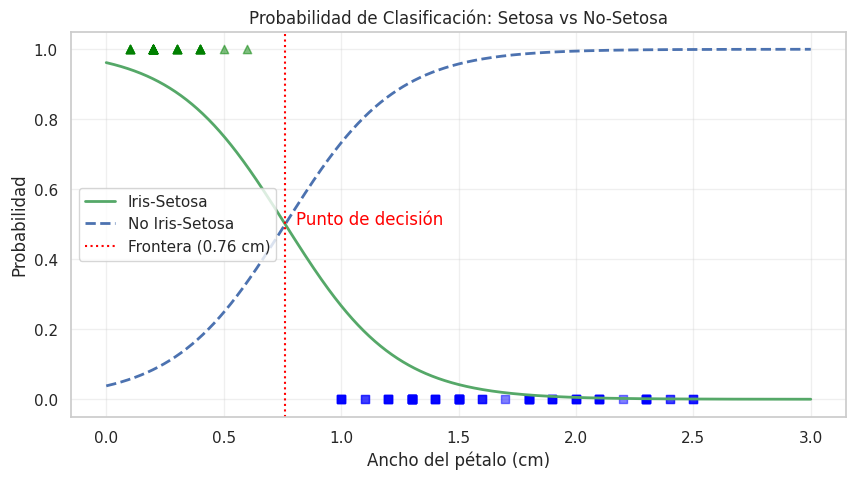

In [17]:
plt.figure(figsize=(10, 5))

# Graficamos la probabilidad de ser Setosa
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris-Setosa")
# Graficamos la probabilidad de NO ser Setosa
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="No Iris-Setosa")

# Dibujamos la frontera de decisión
plt.axvline(decision_boundary, color='red', linestyle=':', label=f"Frontera ({decision_boundary[0]:.2f} cm)")
plt.text(decision_boundary + 0.05, 0.5, "Punto de decisión", color='red')

# Graficamos los puntos reales del entrenamiento para referencia
plt.scatter(X_train_bin[y_train_bin==1], y_train_bin[y_train_bin==1], color='green', marker='^', alpha=0.5)
plt.scatter(X_train_bin[y_train_bin==0], y_train_bin[y_train_bin==0], color='blue', marker='s', alpha=0.5)

plt.title("Probabilidad de Clasificación: Setosa vs No-Setosa")
plt.xlabel("Ancho del pétalo (cm)")
plt.ylabel("Probabilidad")
plt.legend(loc="center left")
plt.grid(True, alpha=0.3)
plt.show()

> **11. Construye el multiclasificador. Puede emplear los metodos dentro de logistic regresión.**

In [18]:
# 1. Definimos las características (X) y el objetivo (y) para el set multiclase
X_train_raw = strat_train_set.drop(["Target"], axis=1).values
y_train_multi = strat_train_set["Target"].values

X_test_raw = strat_test_set.drop(["Target"], axis=1).values
y_test_multi = strat_test_set["Target"].values

# 2. Escalamiento (Indispensable para un modelo robusto)
scaler_iris = StandardScaler()
X_train_scaled = scaler_iris.fit_transform(X_train_raw)
X_test_scaled = scaler_iris.transform(X_test_raw)

# 3. Entrenamos el modelo usando OneVsRestClassifier para evitar el FutureWarning
ovr_model = OneVsRestClassifier(LogisticRegression(solver="lbfgs", max_iter=200, random_state=42))
ovr_model.fit(X_train_scaled, y_train_multi)

accuracy = ovr_model.score(X_test_scaled, y_test_multi)
print(f"Precisión (Accuracy) del multiclasificador OVR escalado: {accuracy * 100:.2f}%")

Precisión (Accuracy) del multiclasificador OVR escalado: 90.00%


> **12. Dado X = [4.9, 5.0, 1.8, 0.3] asociados a todas las caracteristicas, ¿cuál es la probabilidad de que la flor sea setosa, versicolor o virginica?**

Probaremos nuestro modelo con una flor desconocida. El vector de entrada corresponde a:
*   SepalLength: 4.9
*   SepalWidth: 5.0
*   PetalLength: 1.8
*   PetalWidth: 0.3

In [19]:
# --- CORRECCIÓN PUNTO 12: PREDICCIÓN DE MUESTRA ---

# Definimos la muestra solicitada
X_new_flower = np.array([[4.9, 5.0, 1.8, 0.3]])

# ¡MUY IMPORTANTE!: Como el modelo se entrenó con datos escalados,
# debemos escalar esta nueva muestra usando el mismo scaler_iris
X_new_scaled = scaler_iris.transform(X_new_flower)

# Calculamos las probabilidades para cada clase
probabilidades = ovr_model.predict_proba(X_new_scaled)
especie_predicha = ovr_model.predict(X_new_scaled)

print("Resultados de la predicción (Estrategia OVR con escalamiento):")
print(f"Probabilidad de Setosa     (Clase 0): {probabilidades[0][0]:.4f}")
print(f"Probabilidad de Versicolor (Clase 1): {probabilidades[0][1]:.4f}")
print(f"Probabilidad de Virginica  (Clase 2): {probabilidades[0][2]:.4f}")

nombre_especie = iris.target_names[especie_predicha[0]]
print(f"\nLa flor es clasificada como: {nombre_especie.capitalize()}")

Resultados de la predicción (Estrategia OVR con escalamiento):
Probabilidad de Setosa     (Clase 0): 0.9984
Probabilidad de Versicolor (Clase 1): 0.0016
Probabilidad de Virginica  (Clase 2): 0.0000

La flor es clasificada como: Setosa


**Análisis de Mejora de Métricas**

> **Ayudas para mejorar las metricas:**
> * **Normalizar cada columna respecto a su media y desviacion estandar (x-mean(x))/std(x)**
> * **Determinar los datos outlier**
> * **Construir curvas de aprendizaje**

Para que un modelo de clasificación sea robusto, se recomiendan los siguientes pasos adicionales (los cuales ya hemos explorado parcialmente en laboratorios previos):

1.  **Escalamiento (StandardScaler):** Aunque la regresión logística converge en este dataset pequeño, en datasets más grandes el escalamiento (media 0, varianza 1) acelera la convergencia del gradiente.
2.  **Manejo de Outliers:** En la Fase 8 observamos mediante boxplots que algunas variables (como SepalWidth) presentan valores atípicos que podrían sesgar los parámetros $\Theta$.
3.  **Curvas de Aprendizaje:** Graficar el error de entrenamiento vs. validación permite detectar si el modelo sufre de **Sobreajuste** (varianza alta) o **Subajuste** (sesgo alto).

**Conclusión sobre SOFTMAX REGRESION**

> **La elección anterior es conocida com softmax regresión, que permite definir un conjunto de probabilidades asociadas a un conjunto de clases. Al definir el maximo valor de la probabilidad dado un conjunto de inputs se tiene el objeto que predice el modelo.**

La regresión Softmax es la generalización de la logística para múltiples clases. Mientras que la logística usa la sigmoide para una decisión binaria, Softmax calcula una "puntuación" para cada clase y las normaliza para que la suma de todas las probabilidades sea exactamente 1.0. Es la arquitectura base de la última capa de la mayoría de las redes neuronales modernas.

# Parte 3: Clasificación de pulsar

> **Reto, no es obligatorio. Clasificación de pulsar.**
> **Para el siguiente dataset descrito en el este enlace: https://www.google.com/url?sa=E&q=https%3A%2F%2Farchive.ics.uci.edu%2Fdataset%2F372%2Fhtru2, construir un clasificador logístico, para ello, deberá primera entender las caracteristicas del problema y seguidamente estudiar el comportamiento de la clasificacion realizada.**


In [20]:
# Descargamos el dataset usando el ID 372 (HTRU2)
pulsar_dataset = fetch_ucirepo(id=372)

# Extraemos las características y el objetivo
X_pulsar = pulsar_dataset.data.features
y_pulsar = pulsar_dataset.data.targets

# Visualizamos la estructura
print(f"Dimensiones del dataset: {X_pulsar.shape}")
print("\nDistribución de las clases (0: Ruido, 1: Púlsar):")
print(y_pulsar.value_counts())

X_pulsar.head()

Dimensiones del dataset: (17898, 8)

Distribución de las clases (0: Ruido, 1: Púlsar):
class
0        16259
1         1639
Name: count, dtype: int64


,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306


> 1. **Dividir los datos en train and test**

In [21]:
# 1. División estratificada (para mantener la proporción de púlsares raros)
split_pulsar = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split_pulsar.split(X_pulsar, y_pulsar):
    X_train_p = X_pulsar.iloc[train_idx]
    y_train_p = y_pulsar.iloc[train_idx].values.ravel()
    X_test_p = X_pulsar.iloc[test_idx]
    y_test_p = y_pulsar.iloc[test_idx].values.ravel()

# 2. Escalamiento de variables (StandardScaler: media 0, var 1)
scaler_p = StandardScaler()
X_train_scaled = scaler_p.fit_transform(X_train_p)
X_test_scaled = scaler_p.transform(X_test_p)

print("Datos preparados y escalados exitosamente.")

Datos preparados y escalados exitosamente.


> 2. **Entrenar el algoritmo.**


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.94      0.83      0.88       328

    accuracy                           0.98      3580
   macro avg       0.96      0.91      0.94      3580
weighted avg       0.98      0.98      0.98      3580



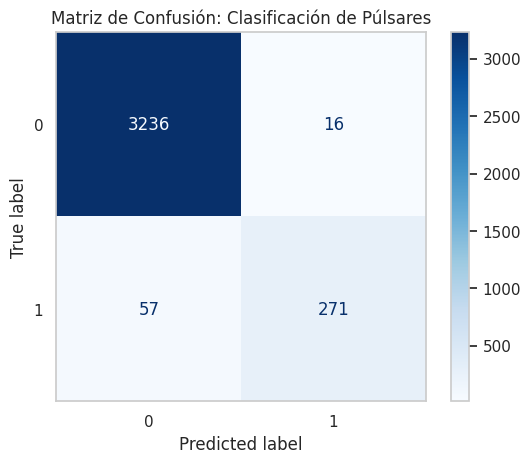

In [22]:
# Entrenamos el modelo con regularización L2 (Ridge) por defecto
# Usamos un valor de C = 1.0 (regularización estándar)
model_pulsar = LogisticRegression(C=1.0, solver='lbfgs', random_state=42)
model_pulsar.fit(X_train_scaled, y_train_p)

# Realizamos predicciones sobre el set de prueba
y_pred_p = model_pulsar.predict(X_test_scaled)

# Evaluación del desempeño
print("--- Reporte de Clasificación ---")
print(classification_report(y_test_p, y_pred_p))

# Matriz de Confusión para ver los falsos negativos (púlsares reales perdidos)
ConfusionMatrixDisplay.from_estimator(model_pulsar, X_test_scaled, y_test_p, cmap='Blues')
plt.title("Matriz de Confusión: Clasificación de Púlsares")
plt.grid(False)
plt.show()

> 3. **Analizar las curvas de aprendizaje.**


En `sklearn`, el parámetro de regularización se llama **`C`**. Es el inverso de $\lambda$ ($C = 1/\lambda$).
*   **C pequeño:** Mucha regularización (parámetros muy pequeños, modelo simple).
*   **C grande:** Poca regularización (modelo más complejo).

Entrenaremos un modelo con regularización equilibrada.

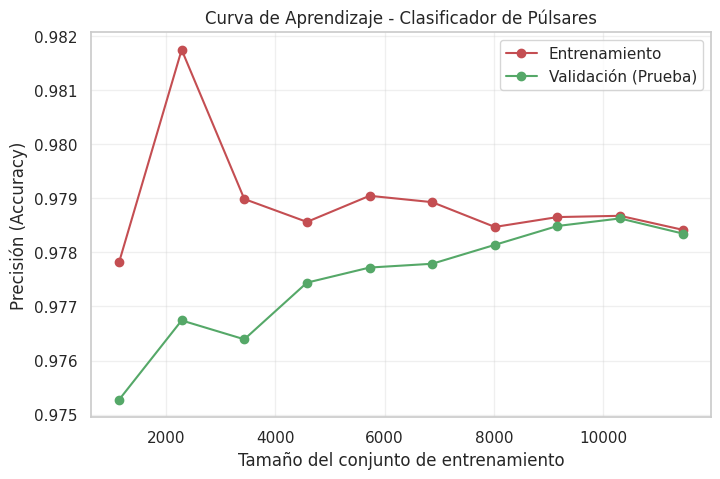

In [23]:
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(C=1.0), X_train_scaled, y_train_p, cv=5,
    scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Promedios de los resultados de validación cruzada
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validación (Prueba)")
plt.title("Curva de Aprendizaje - Clasificador de Púlsares")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión (Accuracy)")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

> 4. **Realizar Predicciones**

In [24]:
# Tomamos 5 muestras al azar del conjunto de prueba escalado
muestras_indices = np.random.choice(len(X_test_scaled), 5, replace=False)
X_ejemplos = X_test_scaled[muestras_indices]
y_reales = y_test_p[muestras_indices]

# Realizamos la predicción
predicciones = model_pulsar.predict(X_ejemplos)
probabilidades = model_pulsar.predict_proba(X_ejemplos)

# Creamos un pequeño resumen
resumen_pred = pd.DataFrame({
    "Clase Real": y_reales,
    "Predicción": predicciones,
    "Prob. Ruido (0)": probabilidades[:, 0].round(4),
    "Prob. Púlsar (1)": probabilidades[:, 1].round(4)
})

print("Predicciones para 5 muestras aleatorias de astrofísica:")
display(resumen_pred)

Predicciones para 5 muestras aleatorias de astrofísica:


,Clase Real,Predicción,Prob. Ruido (0),Prob. Púlsar (1)
0,0,0,0.9923,0.0077
1,0,0,0.9950,0.0050
2,0,0,1.0000,0.0000
3,0,0,0.9948,0.0052
4,0,0,0.9912,0.0088


> 5. **Aplicar regularización.**

In [25]:
# Probamos diferentes niveles de regularización
valores_C = [0.01, 1.0, 100.0]
resultados_reg = []

for c in valores_C:
    temp_model = LogisticRegression(C=c, solver='lbfgs', random_state=42)
    temp_model.fit(X_train_scaled, y_train_p)
    score = temp_model.score(X_test_scaled, y_test_p)
    # Calculamos la norma de los coeficientes
    norma_coef = np.linalg.norm(temp_model.coef_)

    resultados_reg.append({
        "C (Inverso de Lambda)": c,
        "Regularización": "Fuerte" if c < 1 else ("Débil" if c > 1 else "Estándar"),
        # CORRECCIÓN AQUÍ: Usamos round() como función, no como método
        "Precisión (Accuracy)": round(score, 4),
        "Norma de Coeficientes": round(norma_coef, 4)
    })

df_reg = pd.DataFrame(resultados_reg)
display(df_reg)

,C (Inverso de Lambda),Regularización,Precisión (Accuracy),Norma de Coeficientes
0,0.01,Fuerte,0.9768,1.7539
1,1.00,Estándar,0.9796,6.9456
2,100.00,Débil,0.9799,8.2159
